# Ejercicio 4 - Práctica 4

Utilizando el dataset `iris.csv` del Ejercicio N°1:

1. Construya un gráfico que le permita visualizar la distribución de los valores observados del ancho de sépalo. A partir del gráfico realizado, ¿qué puede decir acerca de la simetría de la distribución?

2. Realice un gráfico que permita comparar la distribución del largo del pétalo de las flores entre las distintas especies. Comente brevemente lo observado.

3. Construya un gráfico que le permita analizar la relación general que existe entre las variables ancho y largo del pétalo. ¿Qué observa?

4. Modifique el gráfico realizado en el ítem anterior de tal manera que le permita analizar si la relación general entre el ancho y el largo del pétalo se mantiene según la especie. Comente brevemente lo observado.

5. Construya una matriz de gráficos que le permitan estudiar la asociación que existe entre todos los pares de variables cuantitativas del dataset. Sugerencia: utilice la función `pairplot()` de Seaborn.

6. Sobre las mismas variables cuantitativas del dataset, genere la matriz de correlación lineal de Pearson y represéntela gráficamente a través de un correlograma.

7. A partir de lo realizado en los dos ítems anteriores, caracterice el grado de asociación lineal entre los distintos pares de variables de interés, incluyendo fuerza y dirección, y analizando la correspondencia entre los valores calculados y lo observado gráficamente.

## Caragar el data frame

In [1]:
# Importamos los paquetes necesarios

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../datasets/iris.csv")
df.head()

,id,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Item 1

Construya un gráfico que le permita visualizar la distribución de los valores observados del ancho de sépalo. A partir del gráfico realizado, ¿qué puede decir acerca de la simetría de la distribución?

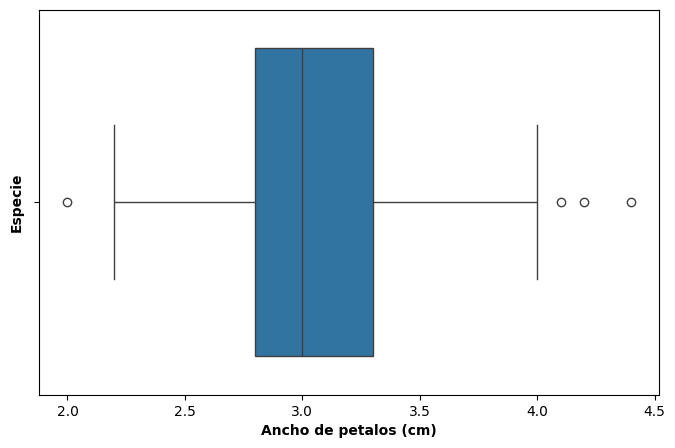

In [3]:
plt.figure(figsize = (8, 5))

sns.boxplot(x = 'sepal_width_cm', data = df)
plt.xlabel('Ancho de petalos (cm)', fontweight = 'bold')
plt.ylabel('Especie', fontweight = 'bold')

plt.show()

La distrubición es levemente asimétrica hacia la derecha.

## Item 2

Realice un gráfico que permita comparar la distribución del largo del pétalo de las flores entre las distintas especies. Comente brevemente lo observado.

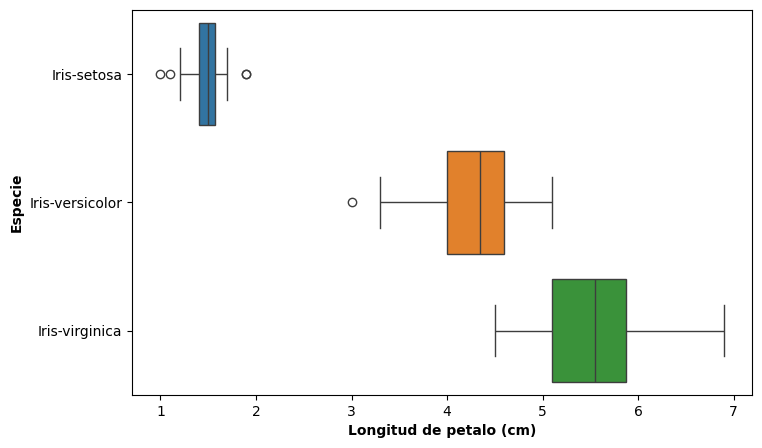

In [6]:
orden = (df.groupby('species')['petal_length_cm'].median().sort_values().index)

plt.figure(figsize = (8, 5))

sns.boxplot(x = 'petal_length_cm', y = 'species',
            hue = 'species', order = orden, data = df)
plt.xlabel('Longitud de petalo (cm)', fontweight = 'bold')
plt.ylabel('Especie', fontweight = 'bold')
plt.show()

La iris virginica es la que presenta mayor longitud de pétalko, seguida de la iris versicolor. La iris setosa tiene una longitud mucho menor que las otras.

## Item 3

Construya un gráfico que le permita analizar la relación general que existe entre las variables ancho y largo del pétalo. ¿Qué observa?

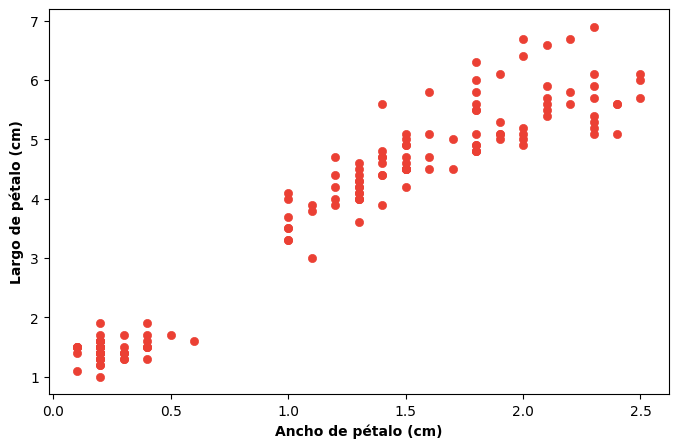

In [7]:
plt.figure(figsize = (8,5))

sns.scatterplot(x = 'petal_width_cm', y = 'petal_length_cm', s = 35, 
                color = '#eb4034', edgecolor = '#eb4034', 
                data = df)

plt.xlabel('Ancho de pétalo (cm)', fontweight = 'bold')
plt.ylabel('Largo de pétalo (cm)', fontweight = 'bold')

plt.show()

Se observa que están relacionadas de manera linealmente positiva fuerte.

## Item 4

Modifique el gráfico realizado en el ítem anterior de tal manera que le permita analizar si la relación general entre el ancho y el largo del pétalo se mantiene según la especie. Comente brevemente lo observado.

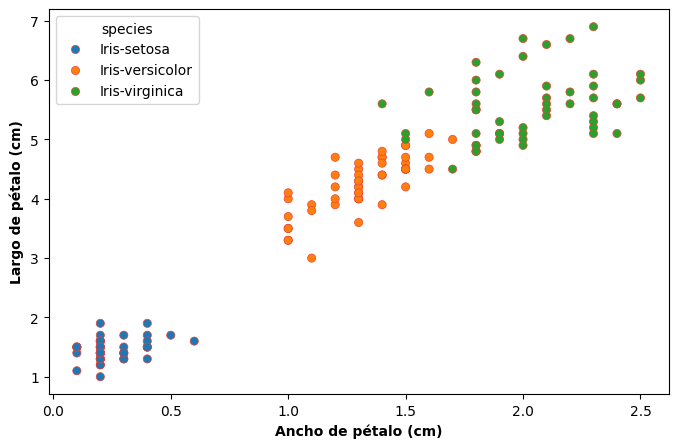

In [8]:
plt.figure(figsize = (8,5))

sns.scatterplot(x = 'petal_width_cm', y = 'petal_length_cm', s = 35, 
                color = '#eb4034', edgecolor = '#eb4034', hue = "species",
                data = df)

plt.xlabel('Ancho de pétalo (cm)', fontweight = 'bold')
plt.ylabel('Largo de pétalo (cm)', fontweight = 'bold')

plt.show()

Se mantiene!

## Item 5

Construya una matriz de gráficos que le permitan estudiar la asociación que existe entre todos los pares de variables cuantitativas del dataset. Sugerencia: utilice la función `pairplot()` de Seaborn.

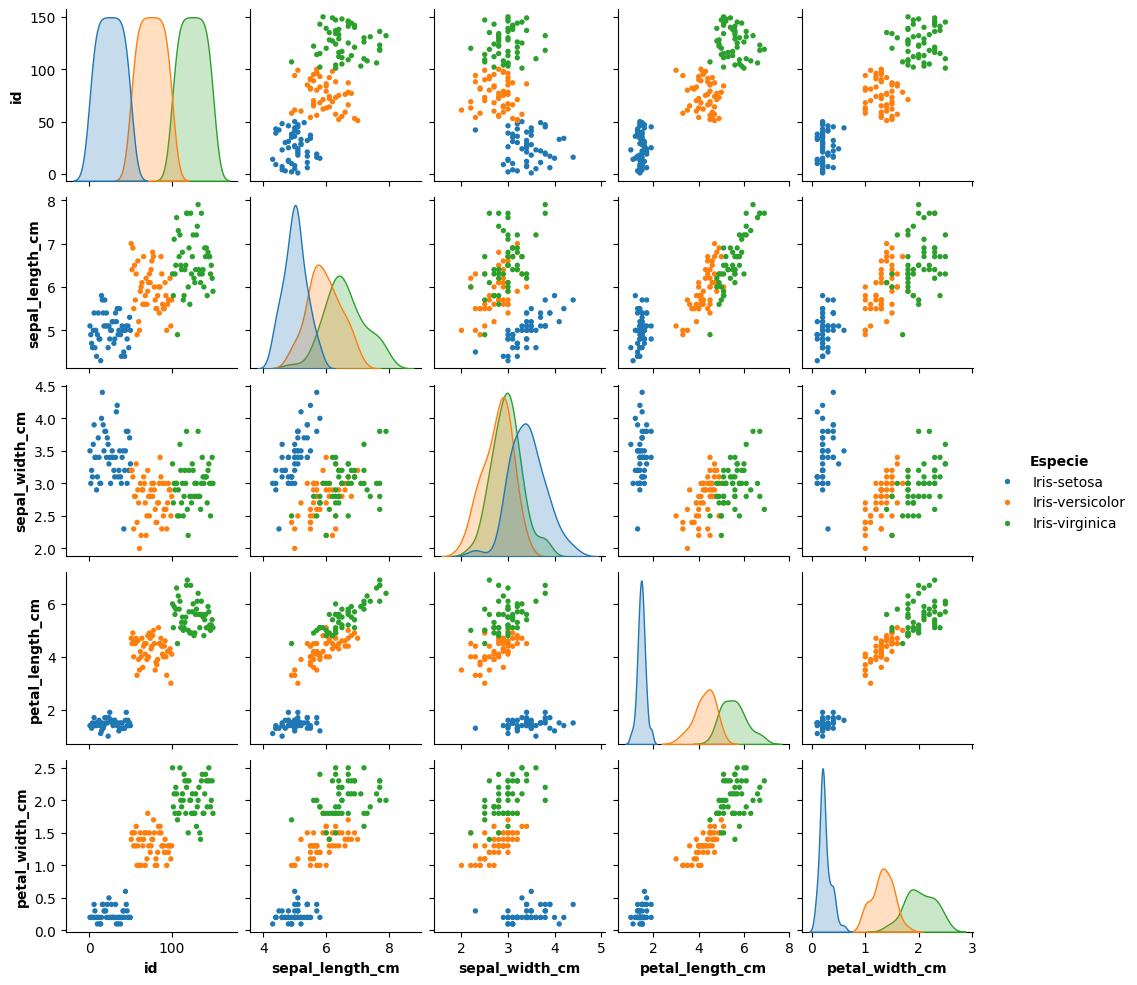

In [12]:
# Diccionario para renombrar columnas
#nombres_ejes = {'bill_length_mm': 'Largo de pico (mm)', 'bill_depth_mm': 'Prof. de pico (mm)',
#                'flipper_length_mm' : 'Largo de aleta (mm)', 'body_mass_g' : 'Masa corporal (g)'}

# DataFrame con columnas renombradas (sólo para plotear)
#data_plot = df.rename(columns = nombres_ejes)

# Renombramos columna 'species' para cambiar fácil el título de la leyenda
df.rename(columns = {'species' : 'Especie'}, inplace = True)

# Construimos la matriz de gráficos, mapeando la especie al color
g = sns.pairplot(
    #vars = list(df.values()),
    hue = 'Especie',
    data = df,
    height = 2,
    plot_kws = {'edgecolor': 'none', 's': 15}
)

# Para que todos los títulos de ejes y el de la leyenda estén en negrita
for ax in g.axes.flatten():
    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontweight('bold')

g._legend.get_title().set_fontweight('bold')

plt.show()

## Item 6

Sobre las mismas variables cuantitativas del dataset, genere la matriz de correlación lineal de Pearson y represéntela gráficamente a través de un correlograma.

In [ ]:
df.corr(method = 'pearson', numeric_only = True)

,id,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
id,1.000000,0.716676,-0.397729,0.882747,0.899759
sepal_length_cm,0.716676,1.000000,-0.109369,0.871754,0.817954
sepal_width_cm,-0.397729,-0.109369,1.000000,-0.420516,-0.356544
petal_length_cm,0.882747,0.871754,-0.420516,1.000000,0.962757
petal_width_cm,0.899759,0.817954,-0.356544,0.962757,1.000000


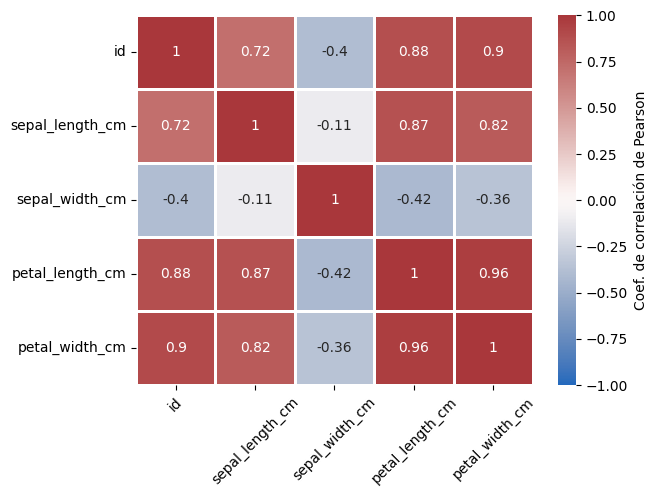

In [29]:

# Matriz de correlación
matriz_cor = df.corr(method = 'pearson', numeric_only = True)

ax = sns.heatmap(matriz_cor,
                annot = True,
                cmap = 'vlag',
                vmin = -1,
                vmax = 1,
                linewidths = 0.9,
                cbar_kws = dict(label = 'Coef. de correlación de Pearson'))

plt.xticks(rotation = 45)

plt.show()

## Item 7

A partir de lo realizado en los dos ítems anteriores, caracterice el grado de asociación lineal entre los distintos pares de variables de interés, incluyendo fuerza y dirección, y analizando la correspondencia entre los valores calculados y lo observado gráficamente.

Completa!